# Prac W3 - Unsupervised Learning

### Aims:

- To complement lecture material in understanding unsupervised learning
- To produce some assessable work for this subject

(**Q1**) Apply the $k$-means clustering algorithm (as implemented in Matlab or python scikit-learn)
to the heightweight dataset (second and third columns). Plot the resulting cluster centres
together with the data. Colour the data according to class label (first column)

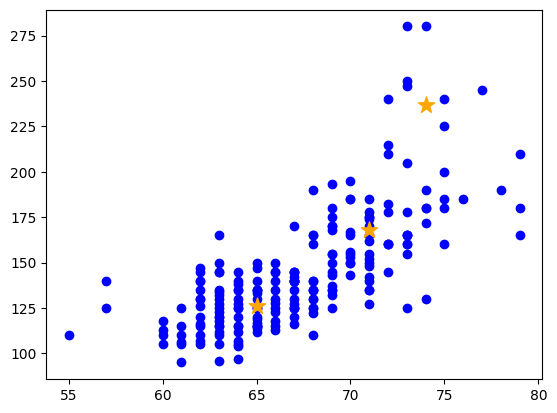

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from typing import List

DATA_FILEPATH: str = "./datasets/HeightWeightData.csv"

def load_data() -> pd.DataFrame:
    return pd.read_csv(DATA_FILEPATH, sep=",", header=None)

class KMeansClustering:
    # Member variables
    k: int
    max_iters: int
    tolerance: float
    centroids: np.ndarray

    # Private methods
    def _init_centroids(self, X: np.ndarray):
        indices: np.array = np.random.choice(X.shape[0], size=self.k, replace=False)
        self.centroids = X[indices]

    def _compute_distance(self, x_1: np.array, x_2: np.array) -> float:
        return np.sqrt(np.sum(np.square(x_1 - x_2)))

    # Public methods
    def __init__(self, k: int = 3, max_iters: int = 100, tolerance: float = 1e-4):
        self.k = k 
        self.max_iters = max_iters
        self.tolerance = tolerance

    def fit(self, X: np.ndarray) -> np.ndarray:
        # Randomly place centroids amongst space
        self._init_centroids(X)

        distance_moved: np.array = np.array(self.k * [sys.float_info.max])
        num_of_iters: int = 0
        while np.max(distance_moved) > self.tolerance and num_of_iters <= self.max_iters:
            # 1. Label data based on closest centroid
            labels_array: List[int] = []

            for x in X:
                distances: np.array = np.array([
                    self._compute_distance(x, centroid) for centroid in self.centroids
                ])

                labels_array.append(np.argmin(distances))

            labels: np.array = np.array(labels_array)

            # 2. Move centroid by taking the mean of the corresponding label data
            for centroid_idx in range(0, self.k):
                indices: np.array = np.where(labels == centroid_idx)
                new_centroid: np.array = np.mean(X[indices], axis=0)
                distance_moved[centroid_idx] = self._compute_distance(
                    self.centroids[centroid_idx], new_centroid
                )
                self.centroids[centroid_idx] = new_centroid

            num_of_iters += 1

        return self.centroids

def plot_kmc(model: KMeansClustering, X: np.ndarray) -> None:
    plt.scatter(X[:, 0], X[:, 1], color="blue")
    plt.scatter(model.centroids[:, 0], model.centroids[:, 1], color="orange", marker="*", s=150)
    plt.show()

df: pd.DataFrame = load_data()
model: KMeansClustering = KMeansClustering(3)
X: np.ndarray = df.iloc[:, 1:].to_numpy()
model.fit(X)
plot_kmc(model, X)

(**Q2**) Write a python function implementing PCA